<!-- parity-note -->
## MATLAB Parity Note
- Source MATLAB helpfile: `StimulusDecode2D.mlx`
- Fidelity status: `high_fidelity`
- Remaining justified differences: The notebook now follows the MATLAB nonlinear-CIF decoding workflow and uses `DecodingAlgorithms.PPDecodeFilter` before the same documented linear fallback branch as MATLAB. Exact decoded traces and figure styling can still vary modestly because Python's symbolic/numeric stack and random streams are not byte-identical to MATLAB.


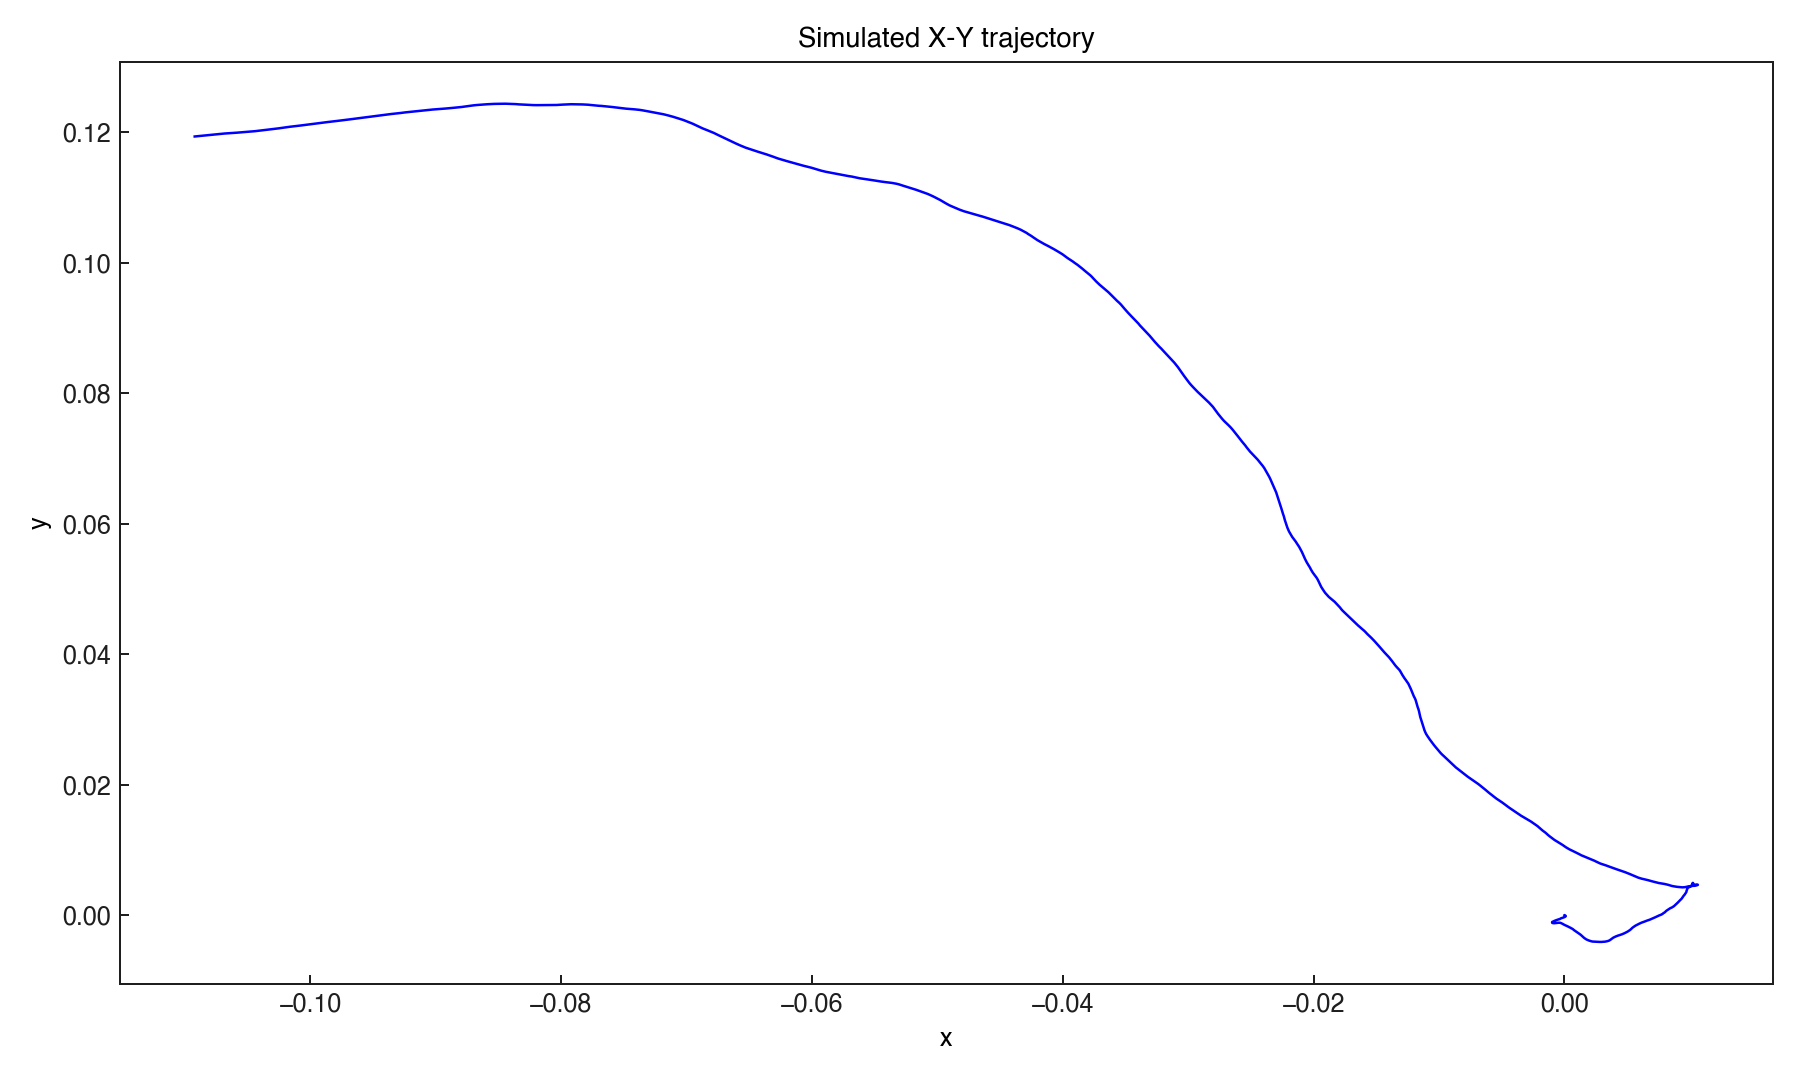

In [ ]:
# nSTAT-python notebook example: StimulusDecode2D
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
SRC_PATH = (REPO_ROOT / "src").resolve()
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import CIF, Covariate, DecodingAlgorithms, SignalObj, nstColl
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
# MATLAB produces 4 figures: trajectory, CIF overlay, place-field subplot grid,
# and predicted-vs-actual path. Mirror that count exactly.
__tracker = FigureTracker(topic='StimulusDecode2D', output_root=OUTPUT_ROOT, expected_count=4)


def _prepare_figure(matlab_line: str, *, figsize=(8.0, 4.5)):
    fig = __tracker.new_figure(matlab_line)
    fig.clear()
    fig.set_size_inches(*figsize)
    return fig


def _subplot_grid(count):
    rows = max(int(np.floor(np.sqrt(count))), 1)
    cols = int(np.ceil(count / rows))
    return rows, cols


def _simulate_decode(seed=0, *, num_realizations=80, delta=0.001, tmax=1.0):
    rng = np.random.default_rng(seed)
    time = np.arange(0.0, tmax + delta, delta)
    q_drive = 0.01
    innovations = q_drive * rng.standard_normal((2, time.size))
    vx = np.cumsum(innovations[0])
    vy = np.cumsum(innovations[1])
    vel_sig = SignalObj(time, np.column_stack([vx, vy]), "vel", "time", "s", "", ["vx", "vy"])
    pos_sig = vel_sig.integral()
    pos_data = np.asarray(pos_sig.data, dtype=float)
    px = pos_data[:, 0]
    py = pos_data[:, 1]

    coeffs = -np.abs(rng.standard_normal((num_realizations, 5)))
    coeffs = np.column_stack([-2.0 * np.abs(rng.standard_normal(num_realizations)), coeffs])
    design = np.column_stack([np.ones(time.size), px, py, px * px, py * py, px * py])

    lambda_rates_hz = np.zeros((time.size, num_realizations), dtype=float)
    lambda_cifs = []
    spike_trains = []
    for idx in range(num_realizations):
        eta = design @ coeffs[idx]
        exp_eta = np.exp(np.clip(eta, -20.0, 20.0))
        lambda_delta = exp_eta / (1.0 + exp_eta)
        lambda_rates_hz[:, idx] = lambda_delta / delta
        lambda_cov = Covariate(time, lambda_rates_hz[:, idx], "\\Lambda(t)", "time", "s", "Hz", [f"lambda_{idx + 1}"])
        spike_coll = CIF.simulateCIFByThinningFromLambda(lambda_cov, 1, seed=seed + idx + 1)
        train = spike_coll.getNST(0)
        train.setName(str(idx + 1))
        spike_trains.append(train)
        lambda_cifs.append(CIF(coeffs[idx], ["1", "x", "y", "x^2", "y^2", "x*y"], ["x", "y"], fitType="binomial"))

    spike_coll = nstColl(spike_trains)
    spike_coll.resample(1.0 / delta)
    labels = list(range(num_realizations))
    dN = spike_coll.dataToMatrix(labels, delta, float(time[0]), float(time[-1])).T

    vx_var = float(np.var(px[1:] - px[:-1]))
    vy_var = float(np.var(py[1:] - py[:-1]))
    q_cov = np.array([[vx_var, 0.0], [0.0, vy_var]], dtype=float)
    p0 = 0.1 * np.eye(2, dtype=float)
    a_mat = np.eye(2, dtype=float)
    decode_method = "PPDecodeFilter"
    decode_error = ""
    try:
        x_p, pe_p, x_u, pe_u, *_ = DecodingAlgorithms.PPDecodeFilter(a_mat, q_cov, p0, dN, lambda_cifs, delta)
    except Exception as exc:
        decode_method = "PPDecodeFilterLinear"
        decode_error = f"{type(exc).__name__}: {exc}"
        mu_linear = coeffs[:, 0]
        beta_linear = coeffs[:, 1:3].T
        x_p, pe_p, x_u, pe_u, *_ = DecodingAlgorithms.PPDecodeFilterLinear(a_mat, q_cov, dN, mu_linear, beta_linear, "binomial", delta)

    # MATLAB grid: meshgrid(-2:.1:2, -2:.1:2). Mirror exactly so each place
    # field renders as a compact Gaussian-like blob rather than a monotone
    # gradient inside a tight (-1.4, 1.4) window.
    grid = np.arange(-2.0, 2.0 + 0.1, 0.1)
    gx, gy = np.meshgrid(grid, grid)
    grid_design = np.column_stack([np.ones(gx.size), gx.ravel(), gy.ravel(), gx.ravel() ** 2, gy.ravel() ** 2, gx.ravel() * gy.ravel()])
    fields = []
    for idx in range(num_realizations):
        eta = grid_design @ coeffs[idx]
        field = (1.0 / (1.0 + np.exp(-np.clip(eta, -20.0, 20.0)))).reshape(gx.shape)
        fields.append(field)
    n_common = min(px.size, x_u.shape[1])
    decode_rmse = float(
        np.sqrt(
            np.mean(
                (x_u[0, :n_common] - px[:n_common]) ** 2
                + (x_u[1, :n_common] - py[:n_common]) ** 2
            )
        )
    )
    return {
        "time_s": time,
        "px": px,
        "py": py,
        "vx": vx,
        "vy": vy,
        "spikes": dN.T,
        "lambda_rates_hz": lambda_rates_hz,
        "fields": np.asarray(fields, dtype=float),
        "grid_x": gx,
        "grid_y": gy,
        "decoded_x": x_u[0, :n_common],
        "decoded_y": x_u[1, :n_common],
        "predicted_x": x_p[0, 1 : n_common + 1],
        "predicted_y": x_p[1, 1 : n_common + 1],
        "decode_rmse": decode_rmse,
        "decode_method": decode_method,
        "decode_error": decode_error,
        "coeffs": coeffs,
        "state_cov": pe_u[:, :, :n_common],
        "num_cells": num_realizations,
    }


def _plot_raster(ax, time_s, spikes, *, max_cells=20):
    n_cells = min(int(spikes.shape[1]), max_cells)
    for row in range(n_cells):
        spike_times = np.asarray(time_s, dtype=float)[np.asarray(spikes[:, row], dtype=float) > 0.5]
        if spike_times.size:
            ax.vlines(spike_times, row + 0.6, row + 1.4, color="k", linewidth=0.35)
    ax.set_ylim(0.5, n_cells + 0.5)
    ax.set_ylabel("cell")


In [2]:
# SECTION 0: 2-D Stimulus Decode
# This notebook follows the MATLAB 2-D decoding workflow with simulated spatial receptive fields.
plt.close("all")
payload = _simulate_decode()
print(
    {
        "num_cells": int(payload["num_cells"]),
        "decode_method": payload["decode_method"],
        "decode_rmse": round(float(payload["decode_rmse"]), 4),
        "fallback_error": payload["decode_error"] or "",
    }
)


{'num_cells': 80, 'decode_method': 'PPDecodeFilter', 'decode_rmse': 0.0823, 'fallback_error': ''}


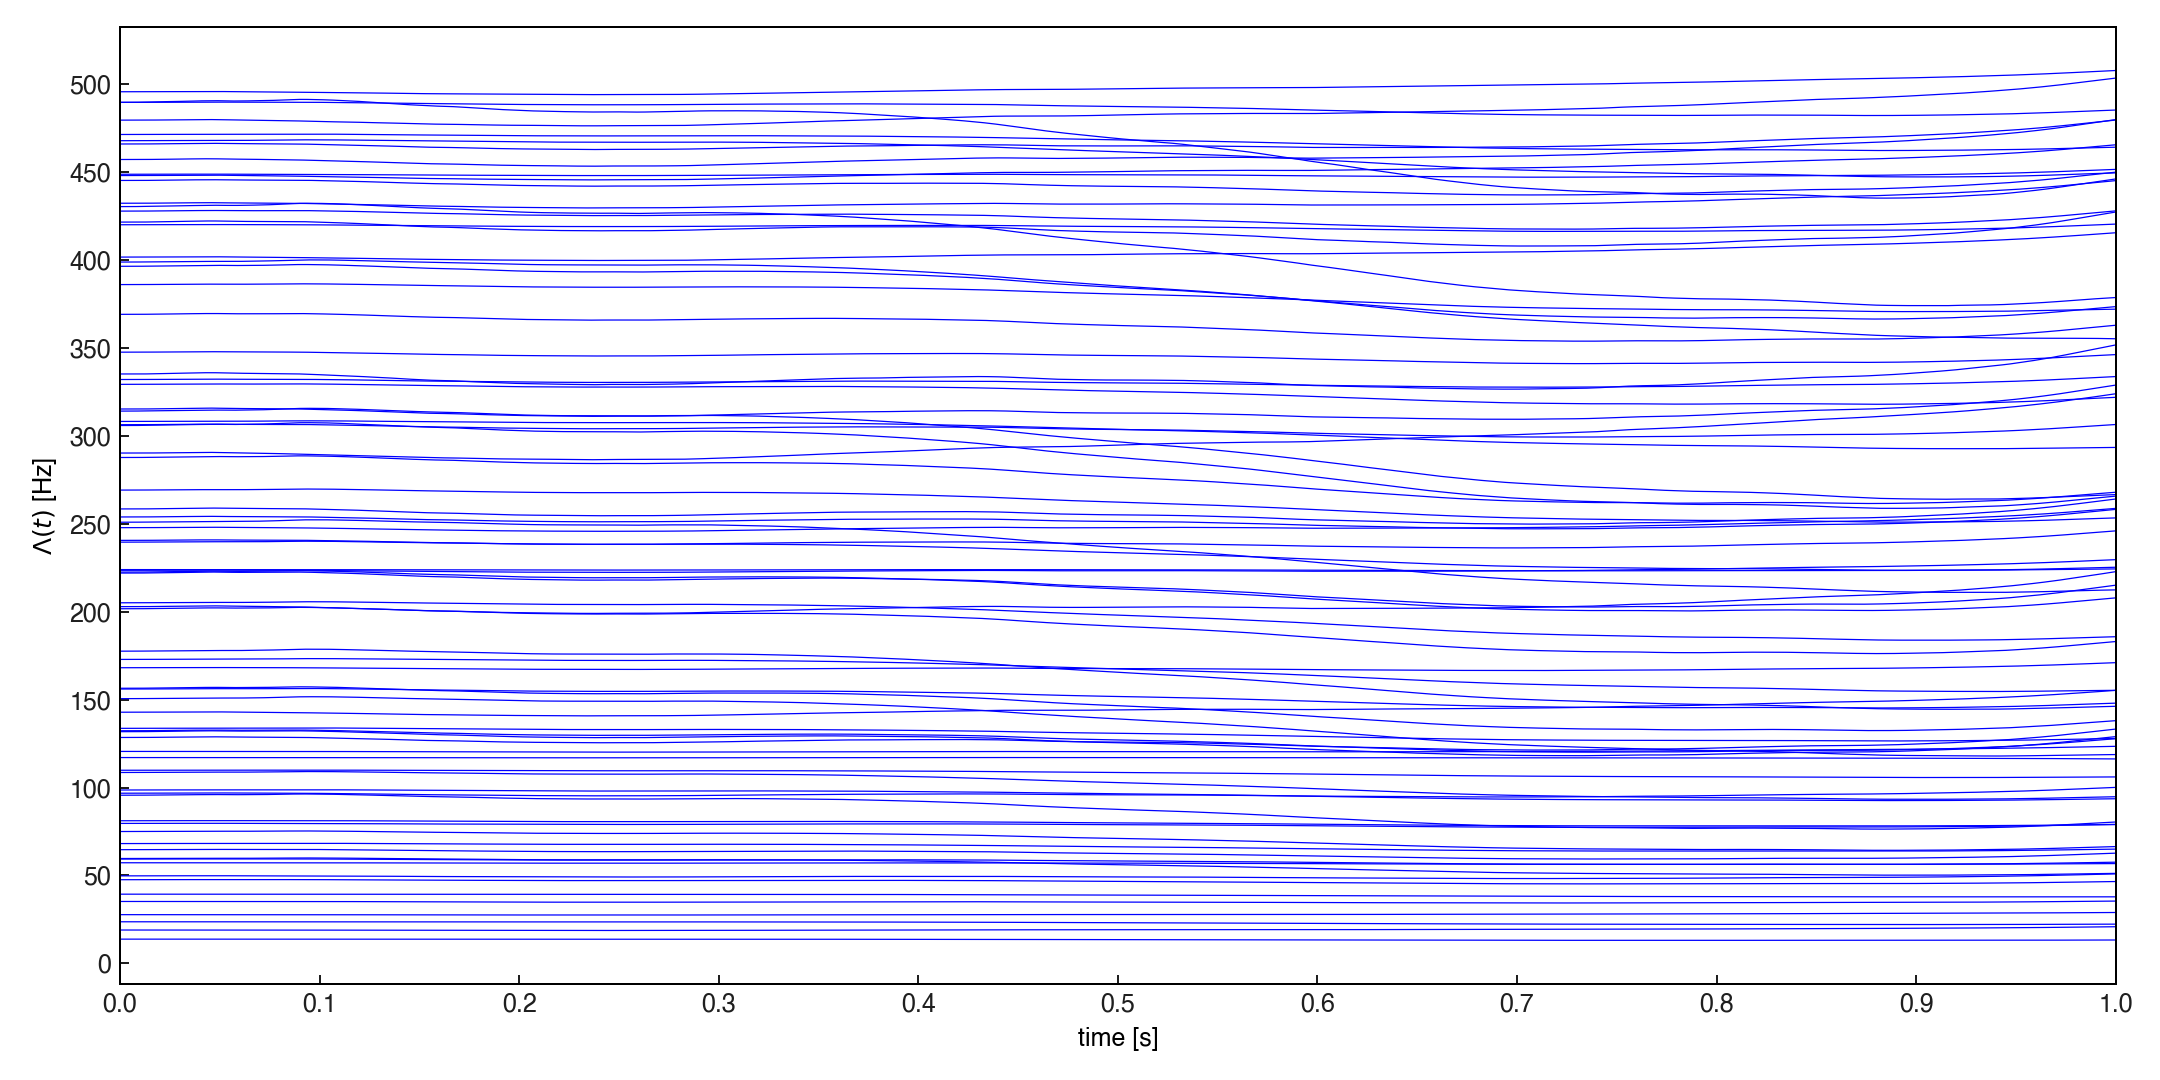

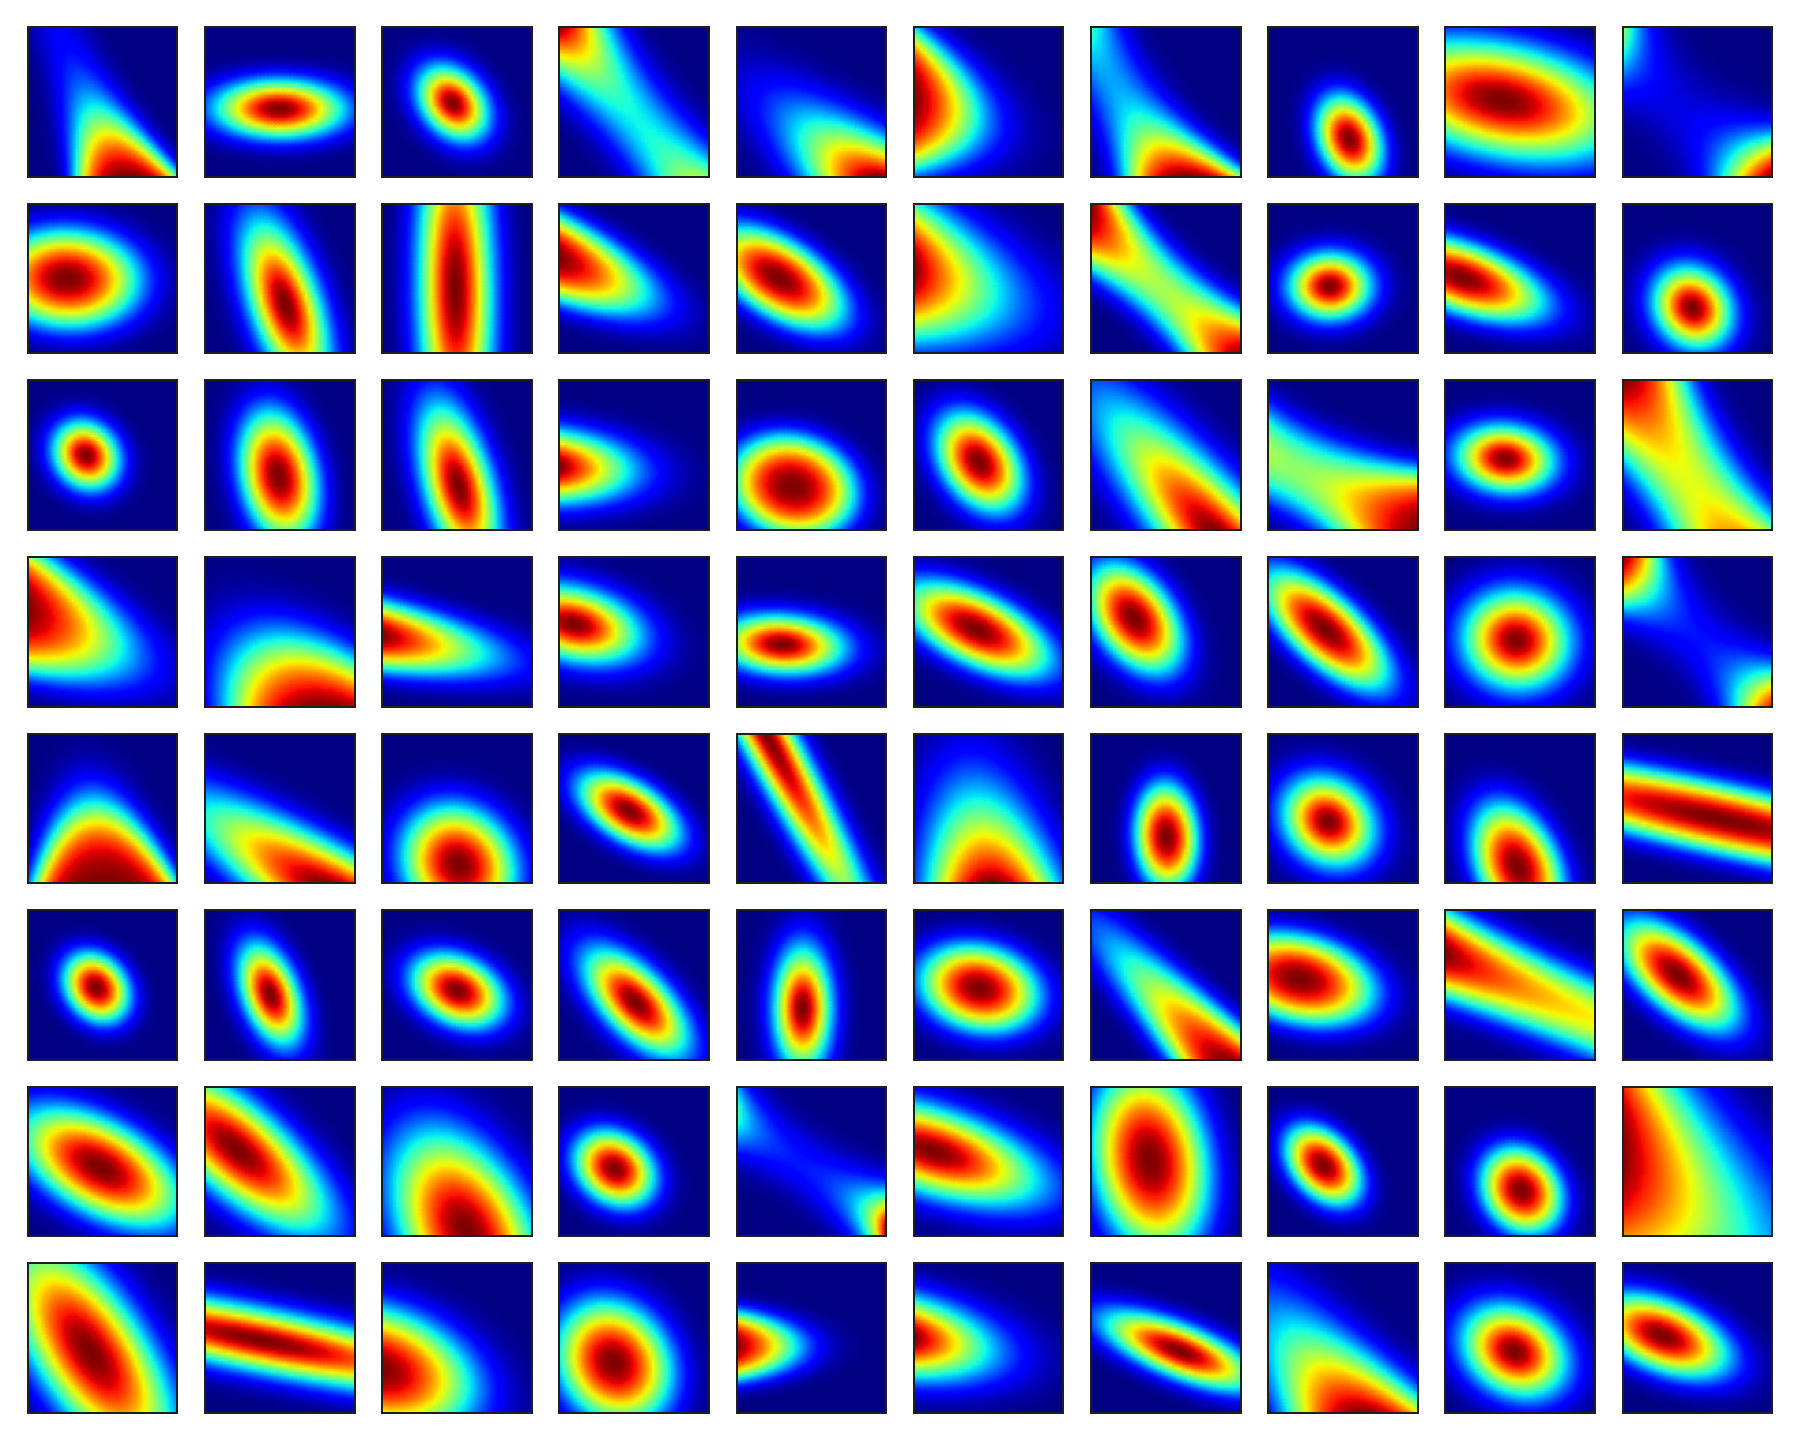

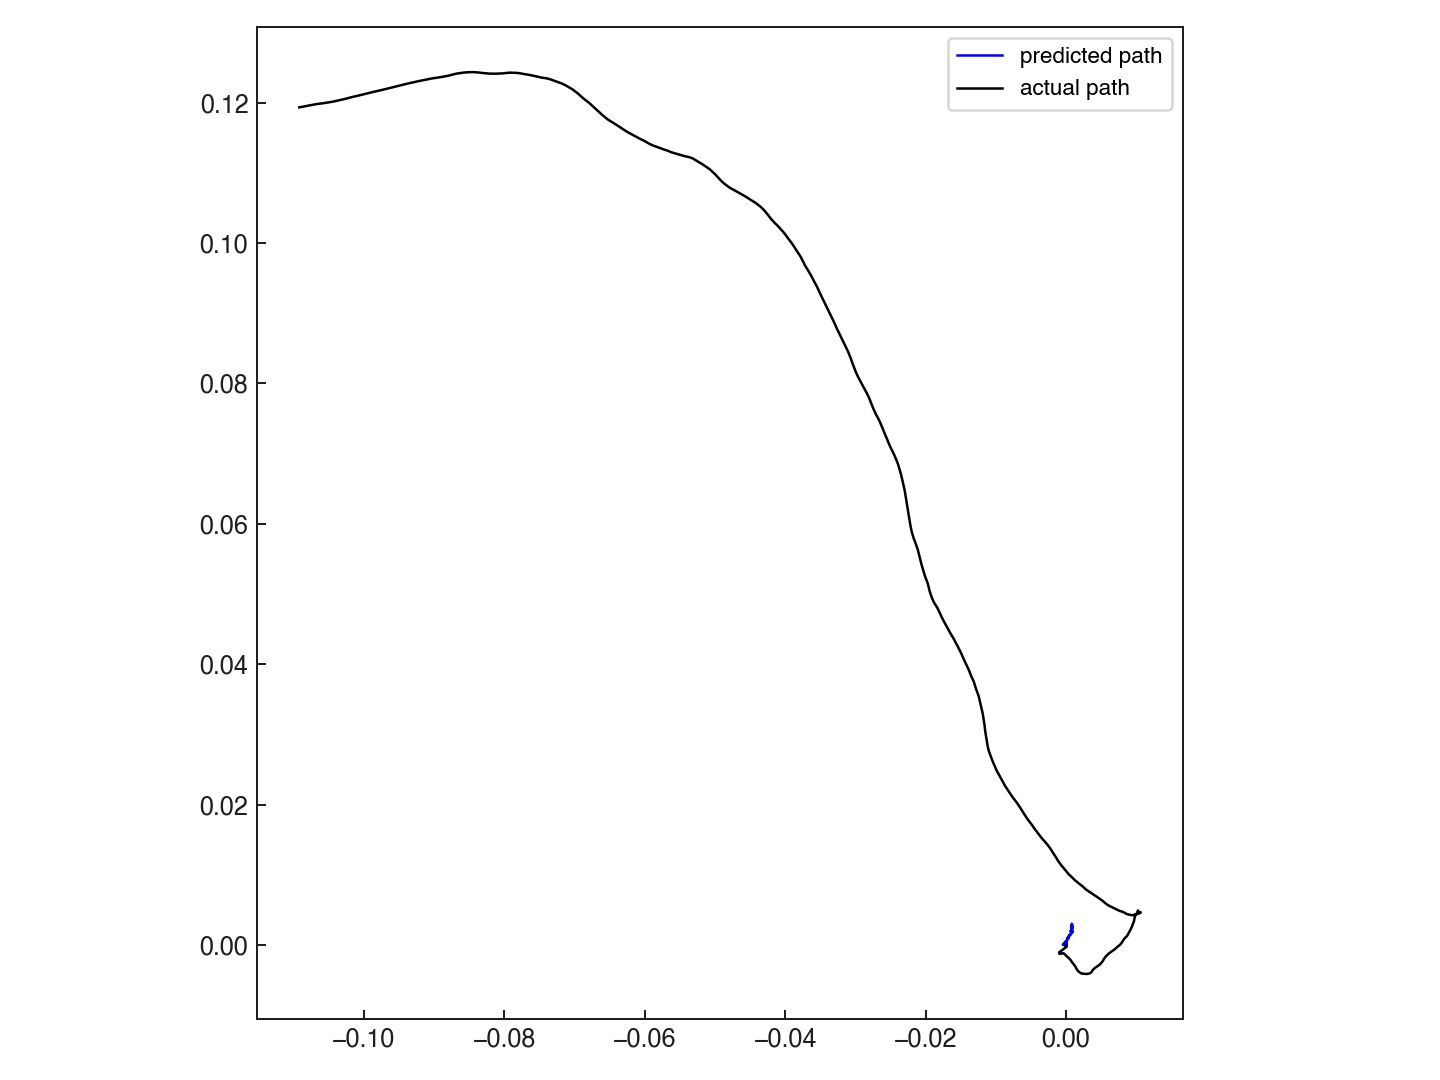

In [ ]:
# SECTION 1: Generate the random receptive fields to simulate different neurons
fig = _prepare_figure("figure; plot(px,py)", figsize=(10.0, 6.0))
ax = fig.subplots(1, 1)
ax.plot(payload["px"], payload["py"], color="b", linewidth=1.0)
ax.set_title("Simulated X-Y trajectory")
ax.set_xlabel("x")
ax.set_ylabel("y")
# MATLAB shows plain boxed axes without gridlines and uses landscape framing
# with default (autoscaled) aspect rather than forced 'equal'.
ax.grid(False)
ax.set_aspect("auto")

from matplotlib.ticker import MultipleLocator as _MultipleLocator
fig = _prepare_figure("lambda{i}.plot", figsize=(12.0, 6.0))
ax = fig.subplots(1, 1)
# Pure MATLAB blue ('b'), opaque, thin lines to match MATLAB's dense CIF rendering.
for idx in range(min(payload["num_cells"], 80)):
    ax.plot(payload["time_s"], payload["lambda_rates_hz"][:, idx], color="b", alpha=1.0, linewidth=0.5)
ax.set_xlabel("time [s]", style="italic")
ax.set_ylabel(r"$\Lambda(t)$ [Hz]", style="italic")
ax.set_xlim(0.0, 1.0)
# Match MATLAB tick density: every 50 Hz on y, every 0.1 s on x.
ax.yaxis.set_major_locator(_MultipleLocator(50))
ax.xaxis.set_major_locator(_MultipleLocator(0.1))
# MATLAB renders a four-sided box; make all spines visible and black.
for spine in ("top", "right", "bottom", "left"):
    ax.spines[spine].set_visible(True)
    ax.spines[spine].set_color("k")

# MATLAB fig 3: subplot grid of ALL numRealizations receptive fields
# (`subplot(fact(1),fact(2),i); pcolor(X,Y,placeField{i}); shading interp`).
# Use the factor decomposition (8x10 for 80 cells) and pcolormesh with
# shading='gouraud' — the direct equivalent of MATLAB's pcolor + shading interp
# (Gouraud-interpolated quads), not imshow with bilinear.
fields_arr = np.asarray(payload["fields"], dtype=float)
gx = payload["grid_x"]
gy = payload["grid_y"]
rows, cols = _subplot_grid(payload["num_cells"])
fig = _prepare_figure("subplot; pcolor(X,Y,placeField{i}), shading interp",
                      figsize=(10.0, 8.0))
axes = fig.subplots(rows, cols)
axes_flat = np.asarray(axes).reshape(-1)
for idx in range(payload["num_cells"]):
    ax = axes_flat[idx]
    f = fields_arr[idx]
    ax.pcolormesh(gx, gy, f, cmap="jet", shading="gouraud",
                  vmin=float(f.min()), vmax=float(f.max()))
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
# Hide any unused tail axes (rows*cols may exceed num_cells).
for j in range(payload["num_cells"], axes_flat.size):
    axes_flat[j].axis("off")
fig.subplots_adjust(wspace=0.05, hspace=0.05)


In [ ]:
# SECTION 2: Decode the x-y trajectory — MATLAB fig 4 (predicted+actual path)
# MATLAB produces ONE predicted-vs-actual figure; do not add a second seed=1
# run (that was a Python-only extension with no MATLAB counterpart).
fig = _prepare_figure("plot(x_u(1,:),x_u(2,:),'b',px,py,'k')", figsize=(8.0, 6.0))
ax = fig.subplots(1, 1)
# MATLAB convention: predicted path in BLUE plotted first (so it appears first
# in the legend), actual path in BLACK plotted second.
ax.plot(payload["decoded_x"], payload["decoded_y"], color="b", linewidth=1.0, label="predicted path")
ax.plot(payload["px"], payload["py"], color="k", linewidth=1.0, label="actual path")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", frameon=True, fontsize=9)
print(f"  decode RMSE = {payload['decode_rmse']:.4f}")
__tracker.finalize()
